# Baseline float training — YOLOv5n (stock SiLU)

Phase 3 of the host-side plan. Trains YOLOv5n (COCO transfer) on the merged drone set, with full control over the run and live assessment of losses / mAP / per-regime metrics / predictions.

**Gate:** mAP@0.5 > 0.85 on val. Track regimes separately — **close / mid / long**, plus a background false-alarm rate (see `data/drone/manifest.csv`).

**Run me with the project venv:** `uv run jupyter lab` (so the kernel sees torch+cu121 and the vendored yolov5).

Cells: setup → config → GPU check → launch (interruptible) → live metrics → per-regime eval → prediction viz → TensorBoard. The metrics/eval/viz cells are re-runnable at any time (during or after training).

## 1. Setup — locate project root, put yolov5 on the path

In [1]:
import os, sys, warnings
from pathlib import Path

# walk up to the project root (the dir containing `yolov5/` and `configs/`)
p = Path.cwd()

while not (p / 'yolov5').exists() and p != p.parent:
    p = p.parent

PROJ = p
os.chdir(PROJ)                      # run everything relative to project root
YOLO = PROJ / 'yolov5'

if str(YOLO) not in sys.path:
    sys.path.insert(0, str(YOLO))  # so `import train`, `import val` resolve

# Vendored yolov5 v7.0 uses the pre-2.4 `torch.cuda.amp.autocast` API (common.py:702,
# train.py:307). Harmless, but AutoShape re-warns on EVERY inference call, so the
# per-image loops in the IoU / background-FP cells bury their own output. Filtered
# here rather than patching the vendored tree, which is pinned. Scoped to this one
# message so other FutureWarnings (e.g. torch.load weights_only) still surface.
AMP_DEPRECATION = r'`torch\.cuda\.amp\.autocast\(args\.\.\.\)` is deprecated'
warnings.filterwarnings('ignore', category=FutureWarning, message=AMP_DEPRECATION)

print('project root :', PROJ)
print('python       :', sys.executable)

project root : /home/alex/Repos/drone-detect
python       : /home/alex/Repos/drone-detect/.venv/bin/python


## 2. Config — all knobs
Edit freely, then run the launch cell. `name` gets auto-suffixed by YOLOv5 if it already exists (baseline, baseline2, ...), unless `exist_ok=True`.

In [2]:
NBS = 64          # YOLOv5's nominal batch size (train.py:153) — all its optimizer
                  # math is pinned to this. batch = NBS * BATCH_MULT.
BATCH_MULT = 3    # 1 = stock regime. >1 multiplies the batch on its value and compensates lr0 /
                  # weight_decay so the training regime is preserved (see build_cmd).

CFG = dict(
    name    = 'more_data_3',  
    # run train or not
    train   = True,                                    
    data    = 'configs/drone.yaml',                     # dataset yaml (abs paths inside)
    weights = 'weights/yolov5n.pt',                     # COCO-pretrained start ('' = from scratch)
    hyp     = 'yolov5/data/hyps/hyp.scratch-low.yaml',  # base augmentation / lr hyperparameters
    # per-experiment hyp tweaks, e.g. {'mosaic': 0.5}
    hyp_overrides = {
        'mosaic': 0.5,
        },                   
    # --- schedule ---
    epochs   = 100,
    patience = 30,        # early-stop if no val improvement for N epochs
    # --- batch / resolution ---
    img   = 640,
    batch = NBS * BATCH_MULT,
    batch_mult = BATCH_MULT,
    # --- runtime ---
    device  = '0',        # GPU index, or 'cpu'
    workers = 12,
    cache   = None,       # None | 'ram' | 'disk'  (ram is fastest if RAM allows)
    seed    = 0,
    # --- output ---
    project  = 'runs/train',
    exist_ok = False,     # True = overwrite `name` instead of suffixing
    resume   = False,     # True = resume last interrupted run (ignores most knobs above)
)

CFG

{'name': 'more_data_3',
 'train': True,
 'data': 'configs/drone.yaml',
 'weights': 'weights/yolov5n.pt',
 'hyp': 'yolov5/data/hyps/hyp.scratch-low.yaml',
 'hyp_overrides': {'mosaic': 0.5},
 'epochs': 100,
 'patience': 30,
 'img': 640,
 'batch': 192,
 'batch_mult': 3,
 'device': '0',
 'workers': 12,
 'cache': None,
 'seed': 0,
 'project': 'runs/train',
 'exist_ok': False,
 'resume': False}

## 3. Environment / GPU check

In [3]:
import torch

print('torch        :', torch.__version__)
print('cuda avail   :', torch.cuda.is_available())

if torch.cuda.is_available():
    print('device       :', torch.cuda.get_device_name(0))
    free, total = torch.cuda.mem_get_info()
    print(f'gpu mem      : {free/1e9:.1f} GB free / {total/1e9:.1f} GB total')
    
assert Path(CFG['weights']).exists(), f"missing weights: {CFG['weights']}"
assert Path(CFG['data']).exists(),    f"missing data yaml: {CFG['data']}"

torch        : 2.4.1+cu121
cuda avail   : True
device       : NVIDIA GeForce RTX 4090
gpu mem      : 23.0 GB free / 25.3 GB total


## 4. Launch training (interruptible)
Runs YOLOv5 `train.py` as a subprocess and streams its progress here. **To stop early:** interrupt the kernel (■ / `Kernel > Interrupt`) — the child process is terminated and the best checkpoint so far is kept in the run dir. Re-run with `resume=True` to continue.

In [4]:
import subprocess, yaml, re

ANSI_RE     = re.compile(r'\x1b\[[0-9;]*m')          # yolov5 colourises its output
WANDB_ID_RE = re.compile(r'/runs/([A-Za-z0-9]{6,})')  # from "wandb: View run at .../runs/<id>"
SAVED_TO_RE = re.compile(r'Results saved to\s+(\S+)')

def derive_hyp(cfg):
    """Return a hyp path that (a) keeps the training regime constant as batch
    scales and (b) applies any per-experiment cfg['hyp_overrides']. Writes a
    derived file so the vendored hyp stays pristine; returns the base path
    untouched when there's nothing to change.

    batch scaling — YOLOv5 pins its optimizer math to nbs=64 (train.py:153-155):
        accumulate    = max(round(64 / batch), 1)      -> 1 for batch >= 64
        weight_decay *= batch * accumulate / 64        -> i.e. multiplied by m
    ...but it never touches lr0. So for batch = 64*m we pre-adjust:
        lr0          *= m   linear scaling rule — m-fold fewer optimizer steps
                            per epoch, so each must be m-fold larger.
        weight_decay /= m   cancels YOLOv5's own *= m, so wd ends at its ORIGINAL
                            value once lr0 is scaled.
    Warmup needs no adjustment: nw = warmup_epochs * nb (train.py:246) and nb
    already shrinks by m, so warmup stays fixed at 3.00 epochs at any batch size
    (the 100-iteration floor only binds above batch ~459).

    overrides — cfg['hyp_overrides'] is applied last, on top of the scaled hyp.
    Keys must already exist in the base hyp; a typo'd key raises rather than
    silently no-op'ing (YOLOv5 ignores unknown hyp keys, so a silent add would
    look like it worked while changing nothing).
    """
    m = cfg.get('batch_mult', 1)
    overrides = cfg.get('hyp_overrides') or {}
    if m == 1 and not overrides:
        return cfg['hyp']                       # pristine base — no derivation

    h = yaml.safe_load(Path(cfg['hyp']).read_text())
    notes = []
    if m > 1:
        lr0_base, wd_base = h['lr0'], h['weight_decay']
        h['lr0'] = lr0_base * m
        h['weight_decay'] = wd_base / m
        notes.append(f"batch_mult={m}: batch={cfg['batch']}  lr0 {lr0_base:g} -> {h['lr0']:g}  "
                     f"weight_decay {wd_base:g} -> {h['weight_decay']:g} "
                     f"(train.py scales it back to {h['weight_decay'] * m:g})")
    for k, v in overrides.items():
        if k not in h:
            raise KeyError(f"hyp_overrides key {k!r} is not in {cfg['hyp']} — "
                           f"YOLOv5 would ignore it. Check the spelling.")
        notes.append(f"override {k}: {h[k]} -> {v}")
        h[k] = v

    out = Path('configs') / f"hyp_gen_{cfg['name']}.yaml"
    out.write_text('# GENERATED by train_baseline.ipynb — do not edit by hand.\n'
                   f"# base={cfg['hyp']}  batch_mult={m}  overrides={overrides}\n"
                   + yaml.safe_dump(h, sort_keys=False))
    print('\n'.join(notes) + f"\nwrote {out}")
    return str(out)


def build_cmd(cfg):
    if cfg.get('resume'):
        return [sys.executable, 'yolov5/train.py', '--resume']
    
    cmd = [sys.executable, 'yolov5/train.py',
           '--data', cfg['data'], 
           '--weights', cfg['weights'], 
           '--hyp', derive_hyp(cfg),
           '--epochs', str(cfg['epochs']), 
           '--patience', str(cfg['patience']),
           '--img', str(cfg['img']), 
           '--batch', str(cfg['batch']),
           '--device', str(cfg['device']), 
           '--workers', str(cfg['workers']),
           '--seed', str(cfg['seed']),
           '--project', cfg['project'], 
           '--name', cfg['name']]
    
    if cfg.get('cache'):    
        cmd += ['--cache', cfg['cache']]
    if cfg.get('exist_ok'): 
        cmd += ['--exist-ok']
    
    return cmd

def run_training(cfg):
    cmd = build_cmd(cfg)
    print('$', ' '.join(cmd), '\n' + '-' * 80)
    # The child is a separate interpreter, so the notebook's warnings filter does not
    # reach it (train.py:307 re-warns once per batch). Same suppression via the env.
    # Message-scoped, so other FutureWarnings still show up in the training log.
    env = dict(os.environ,
               PYTHONWARNINGS='ignore:`torch.cuda.amp.autocast(args...)` is deprecated:FutureWarning')
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1, env=env)
    wandb_id = save_dir = None
    try:
        for line in proc.stdout:
            print(line, end='')
            clean = ANSI_RE.sub('', line)
            if wandb_id is None and 'wandb' in clean:
                m = WANDB_ID_RE.search(clean)
                if m:
                    wandb_id = m.group(1)
            m = SAVED_TO_RE.search(clean)
            if m:
                save_dir = m.group(1)
        proc.wait()
    except KeyboardInterrupt:
        proc.terminate()
        try:
            proc.wait(timeout=10)
        except subprocess.TimeoutExpired:
            proc.kill()
        print('\n[interrupted] training process terminated — best.pt/last.pt kept in run dir')

    # Persist the W&B run id beside the checkpoints so the eval cells can attach
    # their metrics to THIS run. It has to come from stdout: strip_optimizer nulls
    # ckpt['wandb_id'] once training completes, and opt.name is not unique across
    # run dirs (baseline, baseline2, ... all share it).
    if wandb_id and save_dir and Path(save_dir).is_dir():
        (Path(save_dir) / 'wandb_run_id.txt').write_text(wandb_id + '\n')
        print(f'\nW&B run id {wandb_id} -> {save_dir}/wandb_run_id.txt')
    elif wandb_id:
        print(f'\nW&B run id {wandb_id} (no run dir parsed — eval will log to a separate run)')

    return proc.returncode

if CFG["train"]:
    rc = run_training(CFG)
    print('\nexit code:', rc)
else:
    print("Train flag is False, train skipped")

batch_mult=3: batch=192  lr0 0.01 -> 0.03  weight_decay 0.0005 -> 0.000166667 (train.py scales it back to 0.0005)
override mosaic: 1.0 -> 0.5
wrote configs/hyp_gen_more_data_3.yaml
$ /home/alex/Repos/drone-detect/.venv/bin/python yolov5/train.py --data configs/drone.yaml --weights weights/yolov5n.pt --hyp configs/hyp_gen_more_data_3.yaml --epochs 100 --patience 30 --img 640 --batch 192 --device 0 --workers 12 --seed 0 --project runs/train --name more_data_3 
--------------------------------------------------------------------------------
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alex/.netrc.
wandb: Currently logged in as: beatwad to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
train: weights=weights/yolov5n.pt, cfg=, data=configs/drone.yaml, hyp=configs/hyp_gen_more_data_3.yaml, epochs=100, batch_size=192, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cac

## 5. Live metrics — loss & mAP curves + gate check
Reads `results.csv` (YOLOv5 appends a row per epoch). **Re-run this cell any time** while training to refresh the curves. It auto-picks the newest run dir matching `CFG['name']`; override `RUN_DIR` manually if needed.

run dir: runs/train/more_data_3


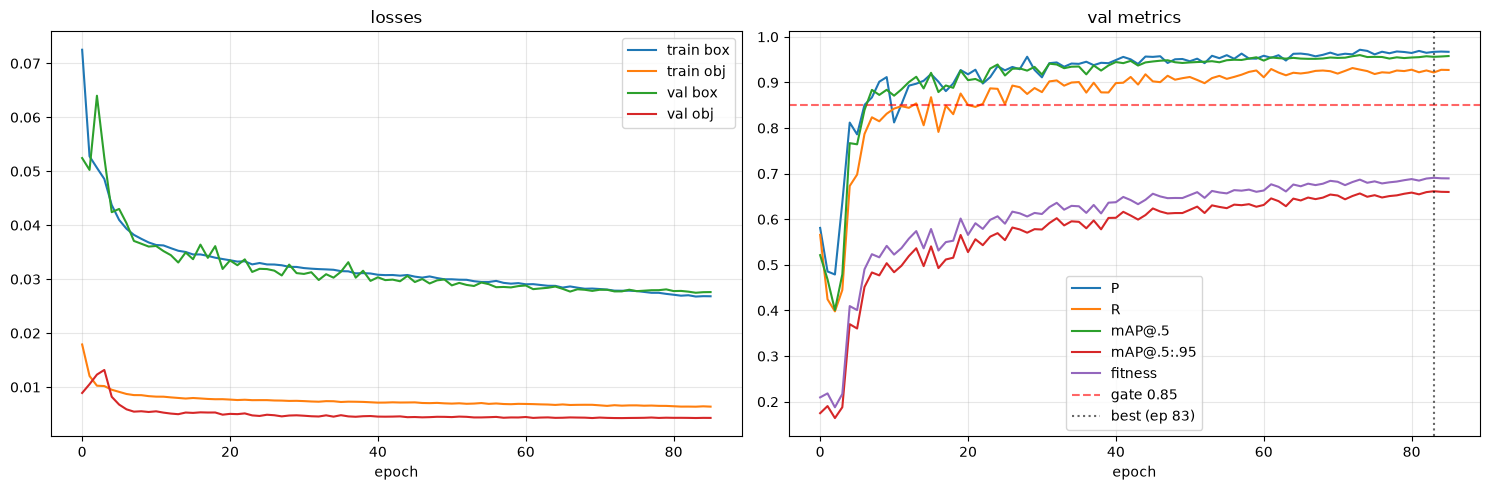

best epoch 83 (fitness = 0.1·mAP@.5 + 0.9·mAP@.5:.95 = 0.6909): mAP@.5=0.9562 mAP@.5:.95=0.6615 P=0.967 R=0.922
GATE mAP@0.5 > 0.85: PASS ✅


In [5]:
import pandas as pd, matplotlib.pyplot as plt

def latest_run(project, name):
    runs = sorted(Path(project).glob(name + '*'), key=lambda d: d.stat().st_mtime)
    return runs[-1] if runs else None

RUN_DIR = latest_run(CFG['project'], CFG['name'])

if CFG["train"]:   # or: RUN_DIR = Path('runs/train/baseline')
    assert RUN_DIR and (RUN_DIR / 'results.csv').exists(), 'no results.csv yet — let training run an epoch'
    print('run dir:', RUN_DIR)

    df = pd.read_csv(RUN_DIR / 'results.csv')
    df.columns = [c.strip() for c in df.columns]

    # YOLOv5 'fitness' — the exact score that selects best.pt & drives early-stop
    # (utils/metrics.py: 0.0*P + 0.0*R + 0.1*mAP@.5 + 0.9*mAP@.5:.95)
    df['fitness'] = 0.1 * df['metrics/mAP_0.5'] + 0.9 * df['metrics/mAP_0.5:0.95']
    best = df.loc[df['fitness'].idxmax()]   # == the epoch YOLOv5 saved as best.pt

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    for c, lbl in [('train/box_loss','train box'), ('train/obj_loss','train obj'),
                ('val/box_loss','val box'),     ('val/obj_loss','val obj')]:
        ax[0].plot(df['epoch'], df[c], label=lbl)

    ax[0].set_title('losses')
    ax[0].set_xlabel('epoch')
    ax[0].legend()
    ax[0].grid(alpha=.3)

    for c, lbl in [('metrics/precision','P'), ('metrics/recall','R'),
                ('metrics/mAP_0.5','mAP@.5'), ('metrics/mAP_0.5:0.95','mAP@.5:.95'),
                ('fitness','fitness')]:
        ax[1].plot(df['epoch'], df[c], label=lbl)

    ax[1].axhline(0.85, ls='--', c='r', alpha=.6, label='gate 0.85')
    ax[1].axvline(best['epoch'], ls=':', c='k', alpha=.6, label=f"best (ep {int(best['epoch'])})")
    ax[1].set_title('val metrics')
    ax[1].set_xlabel('epoch')
    ax[1].legend()
    ax[1].grid(alpha=.3)

    plt.tight_layout()
    plt.show()

    # best epoch ranked by fitness -> matches the checkpoint YOLOv5 wrote to best.pt
    print(f"best epoch {int(best['epoch'])} "
        f"(fitness = 0.1·mAP@.5 + 0.9·mAP@.5:.95 = {best['fitness']:.4f}): "
        f"mAP@.5={best['metrics/mAP_0.5']:.4f} mAP@.5:.95={best['metrics/mAP_0.5:0.95']:.4f} "
        f"P={best['metrics/precision']:.3f} R={best['metrics/recall']:.3f}")
    print('GATE mAP@0.5 > 0.85:', 'PASS ✅' if best['metrics/mAP_0.5'] > 0.85 else 'FAIL ❌')

## 6. Per-regime evaluation (close / mid / long + background)
Aggregate mAP mixes regimes with very different difficulty. This evaluates `best.pt` on each regime's val subset separately — **close-range is our real target metric.** Runs after training finishes (needs `best.pt`).

`regime` is derived per-image from the largest GT box (`close` ≥10% of frame, `long` <1%, `mid` between) by `scripts/merge_dataset.py`, which also writes the `configs/val_<regime>.txt` subsets **from the same run that decides the split** — so they cannot drift out of sync with it. `empty` images have no GT box, so mAP is undefined there; they are scored as a false-alarm rate instead.

In [6]:
import val, wandb

WANDB_LOG = True          # attach eval metrics to the run's W&B entry

best_w = RUN_DIR / 'weights' / 'best.pt'
assert best_w.exists(), f'no best.pt at {best_w} — finish (or interrupt) training first'

def wandb_attach(run_dir, project='YOLOv5'):
    """Resume the training run so eval metrics land ON it rather than beside it.

    The id comes from wandb_run_id.txt, written by run_training from the training
    subprocess's stdout. If it's absent (interrupted run, or evaluating an older
    dir from before this was added) we fall back to a separate '<run>-eval' run
    rather than guessing — several run dirs share the same opt.name, so matching
    by name would silently attach to the wrong run.
    """
    idf = run_dir / 'wandb_run_id.txt'
    if idf.exists():
        return wandb.init(project=project, id=idf.read_text().strip(),
                          resume='must', reinit=True)
    print(f'no {idf.name} in {run_dir} — logging to a separate "{run_dir.name}-eval" run')
    return wandb.init(project=project, name=f'{run_dir.name}-eval', reinit=True)

# regimes that carry ground-truth boxes. `empty` has none, so mAP is undefined
# there and it is scored separately below.
BOXED = ('close', 'mid', 'long')

rows = {}
for regime in BOXED:
    cfg = Path(f'configs/drone_val_{regime}.yaml')
    if not cfg.exists():
        print(f'skip {regime}: {cfg} missing — re-run scripts/merge_dataset.py')
        continue
    res, _, _ = val.run(data=str(cfg), weights=str(best_w),
                        imgsz=CFG['img'], batch_size=CFG['batch'], task='val',
                        device=str(CFG['device']), workers=CFG['workers'],
                        verbose=False, plots=False)
    # res = (mp, mr, map50, map, box_loss, obj_loss, cls_loss)
    rows[regime] = dict(P=res[0], R=res[1], mAP50=res[2], mAP50_95=res[3])

tbl = pd.DataFrame(rows).T
print(tbl.to_string(float_format=lambda x: f'{x:.4f}'))
print('\nclose-range gate mAP@0.5 > 0.85:',
      'PASS ✅' if rows.get('close', {}).get('mAP50', 0) > 0.85 else 'FAIL ❌')

if CFG["train"] and WANDB_LOG and rows:
    wb = wandb_attach(RUN_DIR)
    # scalars -> run summary, so they become sortable/comparable columns in the
    # W&B runs table; the table itself is logged for the full breakdown.
    wb.summary.update({f'eval/{r}/{k}': float(v) for r, d in rows.items() for k, v in d.items()})
    wb.log({'eval/per_regime': wandb.Table(
        dataframe=tbl.reset_index().rename(columns={'index': 'regime'}))})
    print('logged per-regime metrics ->', wb.url)
    wb.finish()

YOLOv5 🚀 2026-7-20 Python-3.11.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)

/home/alex/Repos/drone-detect/yolov5/models/experimental.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related

           P      R  mAP50  mAP50_95
close 0.9748 0.9678 0.9895    0.7247
mid   0.9953 0.9851 0.9944    0.7192
long  0.9521 0.8260 0.8785    0.5470

close-range gate mAP@0.5 > 0.85: PASS ✅
no wandb_run_id.txt in runs/train/more_data_3 — logging to a separate "more_data_3-eval" run


wandb: Currently logged in as: beatwad to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


logged per-regime metrics -> https://wandb.ai/beatwad/YOLOv5/runs/9sva3wvh


eval/close/P,0.97483
eval/close/R,0.96783
eval/close/mAP50,0.98951
eval/close/mAP50_95,0.72465
eval/long/P,0.95209
eval/long/R,0.82598
eval/long/mAP50,0.87852
eval/long/mAP50_95,0.54704
eval/mid/P,0.99527
eval/mid/R,0.98507
+2,...


## 6b. Localization quality — mean IoU
Mean IoU of matched **true-positive** detections vs ground truth (greedy one-to-one matching, `conf ≥ 0.25`, `IoU ≥ 0.5`) — a box-tightness metric, distinct from mAP and directly relevant to **aim precision**. Reported overall + per regime. Needs `best.pt`; reuses the hub `model` from the viz cell if already loaded.

In [7]:
import numpy as np, cv2

CONF_THR = 0.5   # detection confidence threshold
IOU_TP   = 0.50   # IoU >= this counts as a matched true positive

def _iou_matrix(pred, gt):
    if len(pred) == 0 or len(gt) == 0:
        return np.zeros((len(pred), len(gt)))
    ap = (pred[:, 2] - pred[:, 0]) * (pred[:, 3] - pred[:, 1])
    ag = (gt[:, 2] - gt[:, 0]) * (gt[:, 3] - gt[:, 1])
    lt = np.maximum(pred[:, None, :2], gt[None, :, :2])
    rb = np.minimum(pred[:, None, 2:], gt[None, :, 2:])
    wh = np.clip(rb - lt, 0, None)
    inter = wh[..., 0] * wh[..., 1]
    return inter / (ap[:, None] + ag[None, :] - inter + 1e-9)

def _load_gt(img_path, w, h):
    lp = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    boxes = []
    if os.path.exists(lp):
        for line in open(lp):
            s = line.split()
            if len(s) >= 5:
                cx, cy, bw, bh = map(float, s[1:5])
                boxes.append([(cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h])
    return np.array(boxes, float).reshape(-1, 4)

def collect_ious(img_paths):
    """IoU of each greedy one-to-one matched (pred, gt) pair with IoU >= IOU_TP."""
    ious = []
    for ip in img_paths:
        im = cv2.imread(ip)
        if im is None:
            continue
        h, w = im.shape[:2]
        gt = _load_gt(ip, w, h)
        pred = model(ip).xyxy[0].cpu().numpy()          # [x1,y1,x2,y2,conf,cls]
        pred = pred[pred[:, 4] >= CONF_THR][:, :4]
        M = _iou_matrix(pred, gt)
        cand = sorted((M[i, j], i, j) for i in range(M.shape[0]) for j in range(M.shape[1])
                      if M[i, j] >= IOU_TP)
        used_p, used_g = set(), set()
        for v, i, j in reversed(cand):                  # highest IoU first
            if i in used_p or j in used_g:
                continue
            used_p.add(i)
            used_g.add(j)
            ious.append(v)
    return ious

# reuse the hub model if the viz cell already built it, else load best.pt
if 'model' not in globals():
    model = torch.hub.load(str(YOLO), 'custom', path=str(best_w), source='local')
model.conf, model.iou = CONF_THR, 0.45

# BOXED (close/mid/long) comes from the per-regime eval cell — `empty` is skipped
# here since it has no GT boxes to match against.
iou_by_regime = {r: collect_ious(Path(f'configs/val_{r}.txt').read_text().split())
                 for r in BOXED if Path(f'configs/val_{r}.txt').exists()}
iou_by_regime['overall'] = [v for vals in iou_by_regime.values() for v in vals]

iou_tbl = pd.DataFrame({
    r: dict(mean_IoU=(np.mean(v) if v else float('nan')), n_TP=len(v))
    for r, v in iou_by_regime.items()
}).T
print(f'localization quality — mean IoU of matched TPs (conf>={CONF_THR}, IoU>={IOU_TP})')
print(iou_tbl.to_string(float_format=lambda x: f'{x:.4f}'))

if CFG["train"] and WANDB_LOG and any(iou_by_regime.values()):
    wb = wandb_attach(RUN_DIR)          # same run as the per-regime cell
    wb.summary.update({f'eval/{r}/mean_IoU': float(np.mean(v))
                       for r, v in iou_by_regime.items() if v})
    wb.summary.update({f'eval/{r}/n_TP': len(v) for r, v in iou_by_regime.items()})
    wb.summary.update({'eval/iou_conf_thr': CONF_THR, 'eval/iou_tp_thr': IOU_TP})
    wb.log({'eval/mean_iou': wandb.Table(
        dataframe=iou_tbl.reset_index().rename(columns={'index': 'regime'}))})
    print('logged mean-IoU metrics ->', wb.url)
    wb.finish()

YOLOv5 🚀 2026-7-20 Python-3.11.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)

/home/alex/Repos/drone-detect/yolov5/models/experimental.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related

localization quality — mean IoU of matched TPs (conf>=0.5, IoU>=0.5)
         mean_IoU      n_TP
close      0.8604 1485.0000
mid        0.8505 1673.0000
long       0.8117 1336.0000
overall    0.8422 4494.0000
no wandb_run_id.txt in runs/train/more_data_3 — logging to a separate "more_data_3-eval" run


logged mean-IoU metrics -> https://wandb.ai/beatwad/YOLOv5/runs/q6vra854


eval/close/mean_IoU,0.86036
eval/close/n_TP,1485
eval/iou_conf_thr,0.5
eval/iou_tp_thr,0.5
eval/long/mean_IoU,0.8117
eval/long/n_TP,1336
eval/mid/mean_IoU,0.85046
eval/mid/n_TP,1673
eval/overall/mean_IoU,0.84221
eval/overall/n_TP,4494


## 6b-2. Aim precision — mean center error
Distance between predicted and ground-truth **box centers** for matched true positives (same greedy one-to-one matching as 6b: `conf ≥ 0.25`, `IoU ≥ 0.5`). This is the metric the aiming system actually cares about — mAP and mean-IoU are dominated by box *overlap/size*, whereas here it's pure **center localization**. Reported in **pixels** and as a fraction of the image diagonal (resolution-independent ≈ angular error for a fixed FOV), overall + per regime, with the 95th percentile since the tail drives worst-case aim. **Close-range is the target number.** Reuses `model`, `_iou_matrix`, `_load_gt`, `CONF_THR`, `IOU_TP`, `BOXED` from cell 6b — run that first.

In [8]:
def collect_center_errs(img_paths):
    """Center-point error (pred vs GT) of each greedy one-to-one matched TP
    (conf>=CONF_THR, IoU>=IOU_TP). Returns list of (px, frac_of_diag) per pair:
    px is aim error in pixels; frac normalizes by the image diagonal so it's
    comparable across resolutions (~ angular error for a fixed FOV). Matching
    mirrors collect_ious (6b) exactly, only the recorded quantity differs."""
    errs = []
    for ip in img_paths:
        im = cv2.imread(ip)
        if im is None:
            continue
        h, w = im.shape[:2]
        diag = (w ** 2 + h ** 2) ** 0.5
        gt = _load_gt(ip, w, h)
        pred = model(ip).xyxy[0].cpu().numpy()          # [x1,y1,x2,y2,conf,cls]
        pred = pred[pred[:, 4] >= CONF_THR][:, :4]
        M = _iou_matrix(pred, gt)
        cand = sorted((M[i, j], i, j) for i in range(M.shape[0]) for j in range(M.shape[1])
                      if M[i, j] >= IOU_TP)
        used_p, used_g = set(), set()
        for v, i, j in reversed(cand):                  # highest IoU first, one-to-one
            if i in used_p or j in used_g:
                continue
            used_p.add(i)
            used_g.add(j)
            pcx, pcy = (pred[i, 0] + pred[i, 2]) / 2, (pred[i, 1] + pred[i, 3]) / 2
            gcx, gcy = (gt[j, 0] + gt[j, 2]) / 2, (gt[j, 1] + gt[j, 3]) / 2
            d = ((pcx - gcx) ** 2 + (pcy - gcy) ** 2) ** 0.5
            errs.append((d, d / diag))
    return errs


def _summ(v):
    if not v:
        return dict(mean_px=float('nan'), p95_px=float('nan'),
                    mean_frac=float('nan'), p95_frac=float('nan'), n_TP=0)
    px = np.array([e[0] for e in v]); fr = np.array([e[1] for e in v])
    return dict(mean_px=px.mean(), p95_px=np.percentile(px, 95),
                mean_frac=fr.mean(), p95_frac=np.percentile(fr, 95), n_TP=len(v))

err_by_regime = {r: collect_center_errs(Path(f'configs/val_{r}.txt').read_text().split())
                 for r in BOXED if Path(f'configs/val_{r}.txt').exists()}
err_by_regime['overall'] = [e for vals in err_by_regime.values() for e in vals]

err_tbl = pd.DataFrame({r: _summ(v) for r, v in err_by_regime.items()}).T
print(f'aim precision \u2014 center error of matched TPs (conf>={CONF_THR}, IoU>={IOU_TP})')
print(err_tbl.to_string(float_format=lambda x: f'{x:.4f}'))

if CFG["train"] and WANDB_LOG and any(err_by_regime.values()):
    wb = wandb_attach(RUN_DIR)          # same run as the per-regime cell
    for r, v in err_by_regime.items():
        if v:
            s = _summ(v)
            wb.summary.update(
                {
                    f'eval/{r}/center_err_px': float(s['mean_px']),
                    f'eval/{r}/center_err_p95_px': float(s['p95_px']),
                    f'eval/{r}/center_err_frac': float(s['mean_frac']),
                    f'eval/{r}/center_err_p95_frac': float(s['p95_frac']),
                },
            )
    wb.summary.update({f'eval/{r}/n_TP': len(v) for r, v in err_by_regime.items()})
    wb.summary.update({'eval/center_conf_thr': CONF_THR, 'eval/center_tp_thr': IOU_TP})
    wb.log({'eval/center_err': wandb.Table(
        dataframe=err_tbl.reset_index().rename(columns={'index': 'regime'}))})
    print('logged center-error metrics ->', wb.url)
    wb.finish()

aim precision — center error of matched TPs (conf>=0.5, IoU>=0.5)
         mean_px  p95_px  mean_frac  p95_frac      n_TP
close    13.2368 44.0687     0.0134    0.0379 1485.0000
mid       5.3029 14.7458     0.0050    0.0139 1673.0000
long      2.2065  5.7714     0.0021    0.0056 1336.0000
overall   7.0041 24.1818     0.0069    0.0234 4494.0000
no wandb_run_id.txt in runs/train/more_data_3 — logging to a separate "more_data_3-eval" run


logged center-error metrics -> https://wandb.ai/beatwad/YOLOv5/runs/4w0nl4hz


eval/center_conf_thr,0.5
eval/center_tp_thr,0.5
eval/close/center_err_frac,0.01339
eval/close/center_err_p95_frac,0.03794
eval/close/center_err_p95_px,44.06867
eval/close/center_err_px,13.23676
eval/close/n_TP,1485
eval/long/center_err_frac,0.00215
eval/long/center_err_p95_frac,0.00559
eval/long/center_err_p95_px,5.77141
+12,...


## 6c. False positives per regime
Splits the false-positive count across all four val subsets. A false positive is a detection (`conf ≥ 0.25`) that **doesn't** match a ground-truth drone box (greedy one-to-one, `IoU ≥ 0.5`) — a spurious box or an unsuppressed duplicate. On `empty` (no drones) every detection is an FP, so this row equals the background false-alarm rate from cell 6. Logged as the `eval/false_positives` table plus `eval/<regime>/fp_*` summary scalars. Reuses `model`, `_iou_matrix`, `_load_gt`, `BOXED` from cells 6 / 6b, so run those first.

For a kinetic aiming system these are ambiguous/erroneous targets, so it's worth tracking beside mAP — and it's threshold-dependent (raising `CONF_THR` lowers it, at some recall cost).

In [9]:
# reuse model / matcher / thresholds from the per-regime (cell 6) + IoU (6b) cells
model.conf, model.iou = CONF_THR, 0.45

def collect_fps(img_paths, has_gt):
    """Per-regime false positives at conf >= CONF_THR.
    has_gt  (close/mid/long): FP = a prediction not greedily matched to a GT box
                              (IoU >= IOU_TP) — a spurious box or an unsuppressed
                              duplicate on a frame that does contain a drone.
    not has_gt (empty):       every prediction is an FP (no drone present).
    Returns (fp_images, fp_total, n_images). Matching mirrors collect_ious exactly.
    """
    n_fp_img = n_fp_tot = n = 0
    for ip in img_paths:
        im = cv2.imread(ip)
        if im is None:
            continue
        n += 1
        h, w = im.shape[:2]
        pred = model(ip).xyxy[0].cpu().numpy()
        pred = pred[pred[:, 4] >= CONF_THR]
        if not has_gt:
            fp = len(pred)
        else:
            M = _iou_matrix(pred[:, :4], _load_gt(ip, w, h))
            cand = sorted((M[i, j], i, j) for i in range(M.shape[0]) for j in range(M.shape[1])
                          if M[i, j] >= IOU_TP)
            used_p, used_g = set(), set()
            for v, i, j in reversed(cand):            # highest IoU first, one-to-one
                if i in used_p or j in used_g:
                    continue
                used_p.add(i); used_g.add(j)
            fp = len(pred) - len(used_p)              # unmatched predictions
        n_fp_tot += fp
        n_fp_img += (fp > 0)
    return n_fp_img, n_fp_tot, n

fp_rows = {}
for reg in list(BOXED) + ['empty']:
    lst = Path(f'configs/val_{reg}.txt')
    if not lst.exists():
        continue
    fp_img, fp_tot, n = collect_fps(lst.read_text().split(), has_gt=(reg != 'empty'))
    fp_rows[reg] = dict(n_images=n, fp_images=fp_img,
                        fp_image_rate=fp_img / n if n else float('nan'),
                        fp_total=fp_tot,
                        fp_per_image=fp_tot / n if n else float('nan'))

fp_tbl = pd.DataFrame(fp_rows).T[['n_images', 'fp_images', 'fp_image_rate', 'fp_total', 'fp_per_image']]
for c in ('n_images', 'fp_images', 'fp_total'):
    fp_tbl[c] = fp_tbl[c].astype(int)
print(f'false positives per regime (conf>={CONF_THR}, matched at IoU>={IOU_TP})')
print(fp_tbl.to_string(float_format=lambda x: f'{x:.4f}'))

if CFG["train"] and WANDB_LOG and fp_rows:
    wb = wandb_attach(RUN_DIR)          # same run as the eval cells above
    wb.summary.update({f'eval/{reg}/{k}': float(v)
                       for reg, d in fp_rows.items()
                       for k, v in d.items() if k in ('fp_image_rate', 'fp_images', 'fp_total')})
    wb.log({'eval/false_positives': wandb.Table(
        dataframe=fp_tbl.reset_index().rename(columns={'index': 'regime'}))})
    print('logged eval/false_positives ->', wb.url)
    wb.finish()

false positives per regime (conf>=0.5, matched at IoU>=0.5)
       n_images  fp_images  fp_image_rate  fp_total  fp_per_image
close      1574         21         0.0133        21        0.0133
mid        1682         20         0.0119        20        0.0119
long       1607         70         0.0436        70        0.0436
empty       150         22         0.1467        25        0.1667
no wandb_run_id.txt in runs/train/more_data_3 — logging to a separate "more_data_3-eval" run


logged eval/false_positives -> https://wandb.ai/beatwad/YOLOv5/runs/8lq3jxdc


eval/close/fp_image_rate,0.01334
eval/close/fp_images,21
eval/close/fp_total,21
eval/empty/fp_image_rate,0.14667
eval/empty/fp_images,22
eval/empty/fp_total,25
eval/long/fp_image_rate,0.04356
eval/long/fp_images,70
eval/long/fp_total,70
eval/mid/fp_image_rate,0.01189
+2,...


## 7. Prediction visualization
Loads `best.pt` via the vendored yolov5 hub entrypoint and renders detections on random val images sampled **per regime** (close / mid / long) from `manifest.csv`.

detections / image: [1, 1, 1, 1, 0, 1, 0, 0]


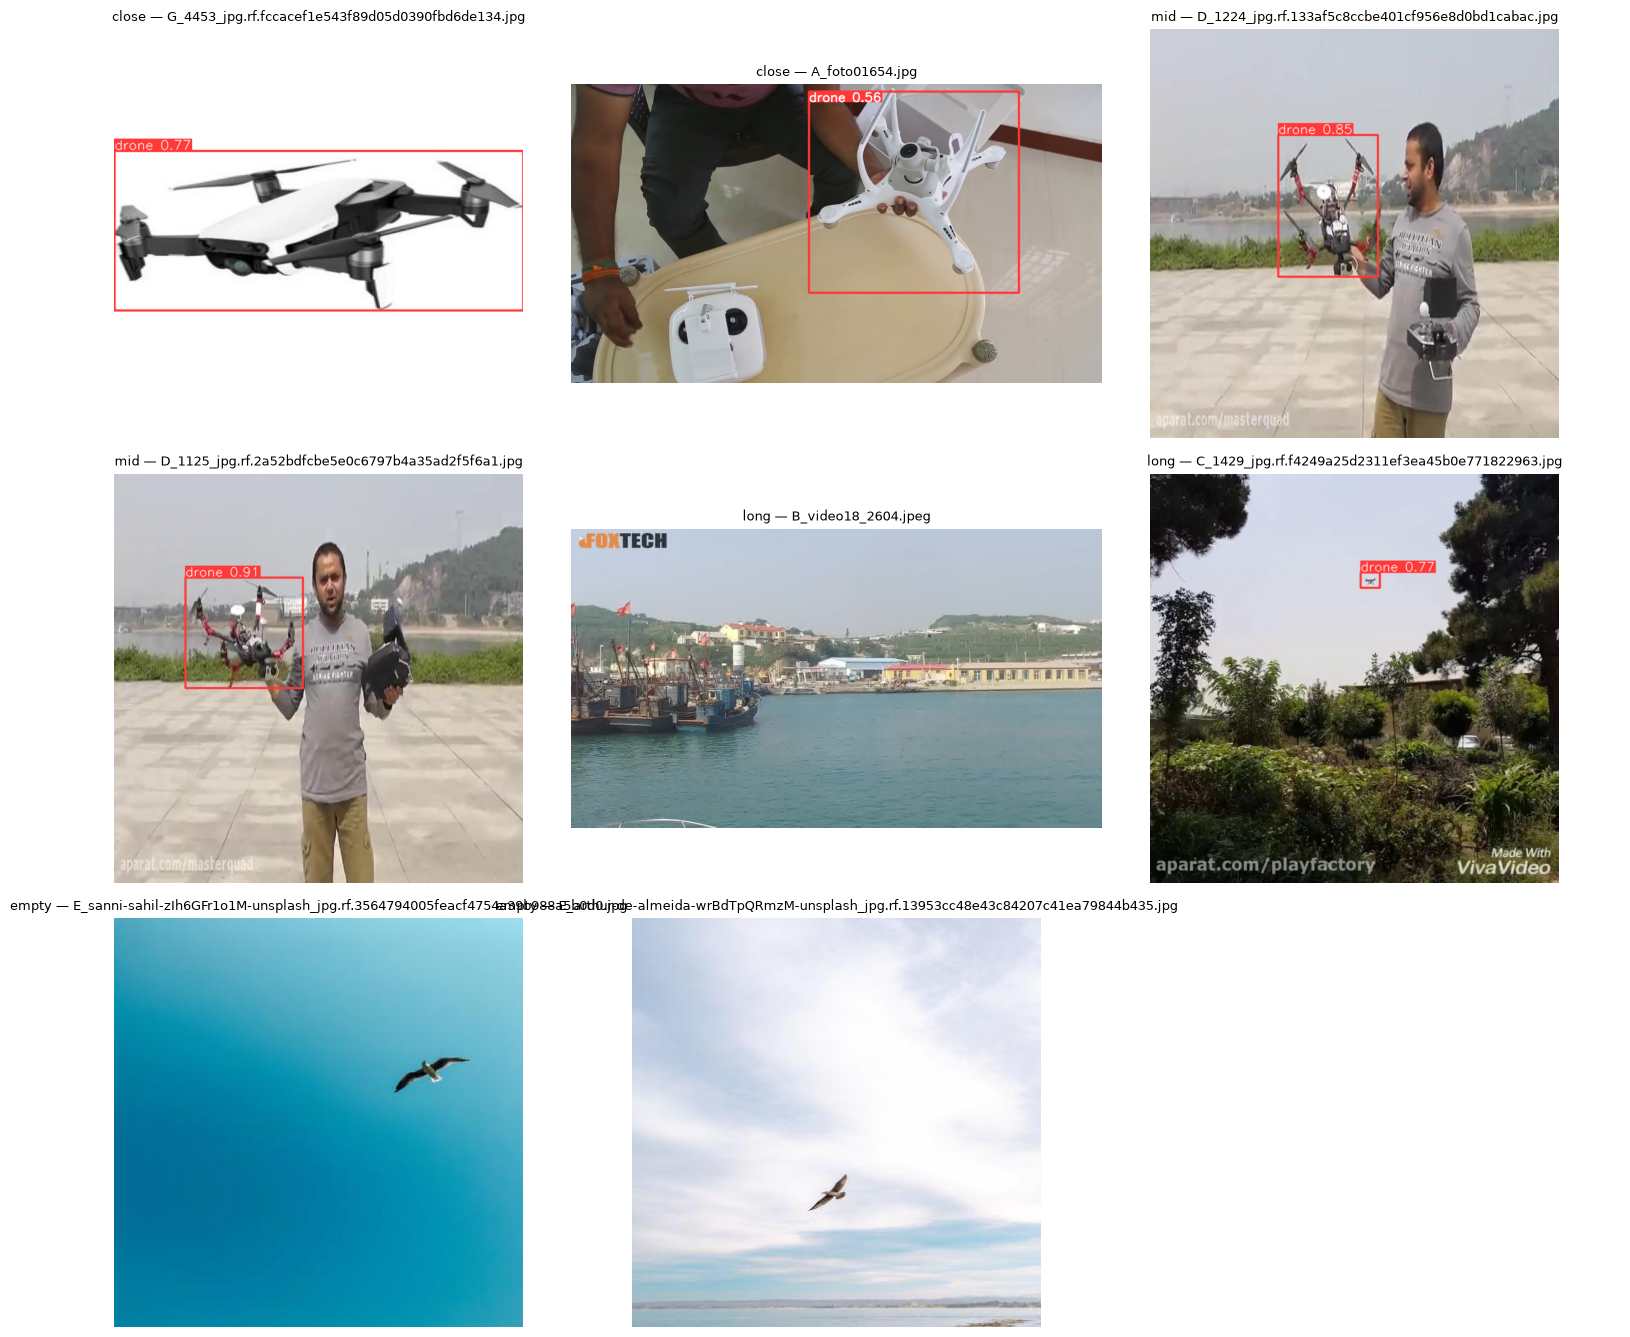

In [10]:
%matplotlib inline
import glob
import torch
import matplotlib.pyplot as plt

# reuse an already-loaded hub model if present, else load best.pt (avoids noisy reload)
if 'model' not in globals():
    model = torch.hub.load(str(YOLO), 'custom', path=str(best_w), source='local')
model.conf, model.iou = 0.25, 0.45

# Sample by REGIME from the manifest, not by source prefix
man = pd.read_csv('data/drone/manifest.csv')
val_man = man[man.split == 'val']

PER_REGIME = 2
imgs, titles = [], []
for reg in ('close', 'mid', 'long', 'empty'):
    sub = val_man[val_man.regime == reg]
    if sub.empty:
        continue
    for stem in sub.sample(min(PER_REGIME, len(sub)), random_state=0).stem:
        hit = glob.glob(f'data/drone/val/images/{stem}.*')
        if hit:
            imgs.append(hit[0])
            titles.append(f'{reg} — {Path(hit[0]).name}')

results = model(imgs)
print('detections / image:', [len(p) for p in results.pred])
results.render()                      # draw boxes into results.ims (RGB)

ncol = 3
nrow = (len(imgs) + ncol - 1) // ncol
fig, ax = plt.subplots(nrow, ncol, figsize=(16, 4.5 * nrow), squeeze=False)

for a, im, t in zip(ax.flat, results.ims, titles):
    a.imshow(im)
    a.axis('off')
    a.set_title(t, fontsize=9)

for a in list(ax.flat)[len(imgs):]:
    a.axis('off')
plt.tight_layout()